# Обучение модели распознавания лиц: ArcFace + Batch-Hard Triplet Loss

Этот ноутбук обучает одну модель распознавания лиц на смеси двух функций потерь:

- **ArcFace Loss** улучшает качество классификации, формируя угловой отступ между классами;
- **Batch-Hard Triplet Loss** улучшает структуру пространства эмбеддингов: изображения одного человека сближаются, разных — раздвигаются.

Архитектура: `ResNet18 (ImageNet) → 128D embedding → ArcFace classifier`.

Общий лосс:

`Total Loss = ARCFACE_WEIGHT × ArcFace Loss + TRIPLET_WEIGHT × Triplet Loss`

Ноутбук содержит подготовку данных, сбалансированный sampler, самостоятельную реализацию ArcFace, Batch-Hard Triplet Loss, обучение, сохранение лучшего checkpoint, графики и итоговую проверку качества.


In [1]:
import random
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models, transforms
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.7.1+cu128
CUDA: 12.8
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## 1. Пути и параметры

### Пояснение основных параметров

- `NUM_CLASSES = 100` — модель обучается на 100 наиболее представленных идентичностях;
- `MAX_TRAIN_IMAGES_PER_CLASS` и `MAX_VAL_IMAGES_PER_CLASS` ограничивают дисбаланс классов и время обучения;
- `EMBEDDING_SIZE = 128` — размер вектора признаков лица;
- `IDENTITIES_PER_BATCH = 8`, `IMAGES_PER_IDENTITY = 4` — каждый batch содержит несколько изображений каждой личности, что необходимо для Batch-Hard Triplet Loss;
- `ARCFACE_SCALE` усиливает logits перед Cross-Entropy;
- `ARCFACE_MARGIN` задаёт дополнительный угловой отступ для истинного класса;
- `TRIPLET_MARGIN` задаёт желаемый зазор между hardest positive и hardest negative;
- `ARCFACE_WEIGHT` и `TRIPLET_WEIGHT` определяют вклад каждого лосса в общий градиент.




In [2]:
PROCESSED_DIR = Path(
    r"D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new"
)

ALIGNED_DIR = PROCESSED_DIR / "aligned_faces_all"
CROPPED_DIR = PROCESSED_DIR / "cropped_faces"

TRAIN_CSV = PROCESSED_DIR / "train_with_identity.csv"
VAL_CSV = PROCESSED_DIR / "val_with_identity.csv"

OUTPUT_DIR = PROCESSED_DIR / "arcface_triplet_loss"
MODELS_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = MODELS_DIR / "arcface_triplet_best.pth"
HISTORY_CSV = OUTPUT_DIR / "arcface_triplet_history.csv"

NUM_CLASSES = 100
MAX_TRAIN_IMAGES_PER_CLASS = 30
MAX_VAL_IMAGES_PER_CLASS = 15

IMAGE_SIZE = (128, 128)
EMBEDDING_SIZE = 128

IDENTITIES_PER_BATCH = 8
IMAGES_PER_IDENTITY = 4

EPOCHS = 50
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 10

ARCFACE_SCALE = 30.0
ARCFACE_MARGIN = 0.50
TRIPLET_MARGIN = 0.30

ARCFACE_WEIGHT = 1.0
TRIPLET_WEIGHT = 1.0

NUM_WORKERS = 0

required_paths = [
    TRAIN_CSV,
    VAL_CSV,
    ALIGNED_DIR,
    CROPPED_DIR,
]

for path in required_paths:
    print(path.exists(), path)

missing = [str(path) for path in required_paths if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Не найдены обязательные файлы:\n" + "\n".join(missing)
    )

print("Checkpoint:", BEST_CHECKPOINT)

True D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\train_with_identity.csv
True D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\val_with_identity.csv
True D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\aligned_faces_all
True D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\cropped_faces
Checkpoint: D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\arcface_triplet_loss\models\arcface_triplet_best.pth


## 2. Подготовка данных

In [3]:
def resolve_image_path(image_id):
    aligned_path = ALIGNED_DIR / str(image_id)

    if aligned_path.exists():
        return aligned_path

    cropped_path = CROPPED_DIR / str(image_id)

    if cropped_path.exists():
        return cropped_path

    return None


# Train и validation читаются из заранее подготовленных CSV.
# Важно, что validation не участвует в обновлении весов:
# она используется только для независимой оценки после каждой эпохи.
train_full_df = pd.read_csv(TRAIN_CSV)
val_full_df = pd.read_csv(VAL_CSV)

# Оставляем 100 наиболее представленных идентичностей в train.
# Это уменьшает дисбаланс классов и делает эксперимент вычислительно доступным.
# Список классов определяется только по train, чтобы validation
# не влияла на выбор обучающих идентичностей.
top_person_ids = (
    train_full_df["person_id"]
    .value_counts()
    .head(NUM_CLASSES)
    .index
    .tolist()
)

# Преобразуем исходные person_id в последовательные метки 0..N-1.
# CrossEntropyLoss и ArcFace ожидают целочисленные индексы классов.
label_mapping = {
    int(person_id): label
    for label, person_id in enumerate(top_person_ids)
}

train_df = train_full_df[
    train_full_df["person_id"].isin(top_person_ids)
].copy()

val_df = val_full_df[
    val_full_df["person_id"].isin(top_person_ids)
].copy()

# Ограничиваем число изображений каждого человека.
# Это снижает доминирование крупных классов над малочисленными.
train_df = (
    train_df
    .groupby("person_id", group_keys=False)
    .head(MAX_TRAIN_IMAGES_PER_CLASS)
    .reset_index(drop=True)
)

val_df = (
    val_df
    .groupby("person_id", group_keys=False)
    .head(MAX_VAL_IMAGES_PER_CLASS)
    .reset_index(drop=True)
)

# Для каждого изображения сначала ищем выровненную версию.
# Если её нет, используем обычный crop как резервный вариант.
train_df["image_path"] = train_df["image_id"].apply(resolve_image_path)
val_df["image_path"] = val_df["image_id"].apply(resolve_image_path)

train_df = train_df[train_df["image_path"].notna()].copy()
val_df = val_df[val_df["image_path"].notna()].copy()

train_df["label"] = train_df["person_id"].map(label_mapping).astype(int)
val_df["label"] = val_df["person_id"].map(label_mapping).astype(int)

# Для Triplet Loss в batch должны присутствовать минимум два
# изображения одной личности. Поэтому исключаем классы, где в train
# осталось меньше двух примеров.
train_counts = train_df["label"].value_counts()
valid_labels = set(train_counts[train_counts >= 2].index)

train_df = train_df[train_df["label"].isin(valid_labels)].copy()
val_df = val_df[val_df["label"].isin(valid_labels)].copy()

print(
    "Train:",
    len(train_df),
    "images /",
    train_df["label"].nunique(),
    "classes",
)

print(
    "Val:",
    len(val_df),
    "images /",
    val_df["label"].nunique(),
    "classes",
)


Train: 1196 images / 100 classes
Val: 77 images / 49 classes


In [4]:
# Train-аугментации имитируют естественные изменения изображения:
# отражение, небольшой поворот и изменение освещения.
# Они применяются только к train, чтобы validation оставалась стабильной
# и отражала качество на неизменённых данных.
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# Для validation используются только детерминированные операции.
# Случайные аугментации здесь запрещены, иначе метрика менялась бы
# между запусками и была бы менее воспроизводимой.
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class FaceIdentityDataset(Dataset):
    """Датасет изображений лиц с метками идентичностей.

    Возвращает:
        image: тензор изображения после преобразований;
        label: индекс класса для CE/ArcFace;
        image_id: исходное имя файла для анализа ошибок.
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = cv2.imread(str(row["image_path"]))

        if image is None:
            raise FileNotFoundError(
                f"Не удалось прочитать {row['image_path']}"
            )

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(int(row["label"]), dtype=torch.long)

        return image, label, str(row["image_id"])


train_dataset = FaceIdentityDataset(train_df, train_transform)
val_dataset = FaceIdentityDataset(val_df, val_transform)


## 3. Balanced batches для Triplet Loss

In [5]:
class BalancedBatchSampler(Sampler):
    """Формирует batch по схеме P × K.

    P = identities_per_batch разных людей;
    K = images_per_identity изображений каждого человека.

    Такое построение обязательно для metric learning: у каждого anchor
    внутри batch должны существовать positive и negative примеры.
    """
    def __init__(
        self,
        labels,
        identities_per_batch,
        images_per_identity,
        batches_per_epoch=None,
        seed=42,
    ):
        self.labels = np.asarray(labels)
        self.identities_per_batch = identities_per_batch
        self.images_per_identity = images_per_identity
        self.batch_size = identities_per_batch * images_per_identity
        self.seed = seed
        self.epoch = 0

        self.indices_by_label = defaultdict(list)

        for index, label in enumerate(self.labels):
            self.indices_by_label[int(label)].append(index)

        self.unique_labels = np.asarray(
            sorted(self.indices_by_label.keys())
        )

        if len(self.unique_labels) < identities_per_batch:
            raise ValueError(
                "Количество классов меньше identities_per_batch"
            )

        if batches_per_epoch is None:
            batches_per_epoch = max(
                1,
                len(self.labels) // self.batch_size,
            )

        self.batches_per_epoch = batches_per_epoch

    def __len__(self):
        return self.batches_per_epoch

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)

        for _ in range(self.batches_per_epoch):
            # Сначала случайно выбираем P разных идентичностей.
            selected_labels = rng.choice(
                self.unique_labels,
                size=self.identities_per_batch,
                replace=False,
            )

            batch_indices = []

            for label in selected_labels:
                class_indices = np.asarray(
                    self.indices_by_label[int(label)]
                )

                replace = (
                    len(class_indices) < self.images_per_identity
                )

                # Затем выбираем K изображений выбранной личности.
                # Если изображений меньше K, разрешаем повторный выбор.
                selected_indices = rng.choice(
                    class_indices,
                    size=self.images_per_identity,
                    replace=replace,
                )

                batch_indices.extend(selected_indices.tolist())

            rng.shuffle(batch_indices)
            yield batch_indices


train_batch_sampler = BalancedBatchSampler(
    labels=train_df["label"].to_numpy(),
    identities_per_batch=IDENTITIES_PER_BATCH,
    images_per_identity=IMAGES_PER_IDENTITY,
    seed=SEED,
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print(
    "Balanced batch size:",
    IDENTITIES_PER_BATCH * IMAGES_PER_IDENTITY,
)


Train batches: 37
Val batches: 2
Balanced batch size: 32


## 4. ArcFace + Triplet модель

In [6]:
class ArcFaceLayer(nn.Module):
    """Собственная реализация ArcFace classification head.

    ArcFace работает не с обычными линейными logits, а с углами между
    L2-нормализованным эмбеддингом и L2-нормализованными весами классов.
    Для истинного класса к углу добавляется margin m, после чего logits
    умножаются на scale s и передаются в CrossEntropyLoss.
    """
    def __init__(
        self,
        in_features,
        num_classes,
        s=30.0,
        m=0.50,
    ):
        super().__init__()

        self.in_features = in_features
        self.num_classes = num_classes
        self.s = s
        self.m = m

        self.cos_m = np.cos(m)
        self.sin_m = np.sin(m)
        self.th = np.cos(np.pi - m)
        self.mm = np.sin(np.pi - m) * m

        self.weight = nn.Parameter(
            torch.empty(num_classes, in_features)
        )
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # Нормализация переводит признаки и веса на единичную сферу.
        # После этого скалярное произведение равно cosine similarity.
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight = F.normalize(self.weight, p=2, dim=1)

        cosine = F.linear(embeddings, weight).clamp(-1.0, 1.0)

        sine = torch.sqrt(
            torch.clamp(
                1.0 - cosine.pow(2),
                min=1e-7,
            )
        )

        # cos(theta + m) = cos(theta)cos(m) - sin(theta)sin(m).
        # Угловой margin применяется только к правильному классу.
        phi = (
            cosine * self.cos_m
            - sine * self.sin_m
        )

        phi = torch.where(
            cosine > self.th,
            phi,
            cosine - self.mm,
        )

        # one_hot-маска позволяет заменить cosine на phi
        # только в столбце истинного класса каждого изображения.
        one_hot = torch.zeros_like(cosine)

        one_hot.scatter_(
            1,
            labels.view(-1, 1).long(),
            1,
        )

        logits = (
            one_hot * phi
            + (1.0 - one_hot) * cosine
        )

        return logits * self.s


class ArcFaceTripletModel(nn.Module):
    def __init__(
        self,
        num_classes,
        embedding_size=128,
        s=30.0,
        m=0.50,
    ):
        super().__init__()

        # Допустимое transfer learning:
        # backbone предобучен на ImageNet, а НЕ на распознавании лиц.
        # Поэтому условие задания о запрете face-pretrained моделей соблюдено.
        backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        backbone_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone

        # Стандартный классификационный слой ResNet заменяется
        # на компактный 128-мерный embedding head.
        self.embedding_head = nn.Sequential(
            nn.Linear(
                backbone_features,
                embedding_size,
            ),
            nn.BatchNorm1d(embedding_size),
        )

        self.arcface = ArcFaceLayer(
            in_features=embedding_size,
            num_classes=num_classes,
            s=s,
            m=m,
        )

        self.embedding_size = embedding_size
        self.num_classes = num_classes

    def forward(self, images, labels=None):
        features = self.backbone(images)

        raw_embeddings = self.embedding_head(features)

        embeddings = F.normalize(
            raw_embeddings,
            p=2,
            dim=1,
        )

        if labels is None:
            return embeddings

        logits = self.arcface(
            embeddings,
            labels,
        )

        return embeddings, logits


model = ArcFaceTripletModel(
    num_classes=NUM_CLASSES,
    embedding_size=EMBEDDING_SIZE,
    s=ARCFACE_SCALE,
    m=ARCFACE_MARGIN,
).to(DEVICE)

print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}",
)


Parameters: 11,255,232


## 5. Batch-Hard Triplet Loss

In [7]:
class BatchHardTripletLoss(nn.Module):
    """Batch-Hard Triplet Loss.

    Для каждого anchor выбирается:
    - hardest positive: самый далёкий пример того же человека;
    - hardest negative: самый близкий пример другого человека.

    Лосс заставляет negative быть дальше positive минимум на margin.
    """
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        # Полная матрица попарных евклидовых расстояний в batch.
        distances = torch.cdist(
            embeddings,
            embeddings,
            p=2,
        )

        labels = labels.view(-1)

        same_identity = labels[:, None] == labels[None, :]
        different_identity = ~same_identity

        diagonal = torch.eye(
            len(labels),
            dtype=torch.bool,
            device=labels.device,
        )

        positive_mask = same_identity & ~diagonal
        negative_mask = different_identity

        # Максимальное расстояние среди положительных примеров.
        hardest_positive = (
            distances
            .masked_fill(~positive_mask, float("-inf"))
            .max(dim=1)
            .values
        )

        # Минимальное расстояние среди отрицательных примеров.
        hardest_negative = (
            distances
            .masked_fill(~negative_mask, float("inf"))
            .min(dim=1)
            .values
        )

        valid = (
            torch.isfinite(hardest_positive)
            & torch.isfinite(hardest_negative)
        )

        if not valid.any():
            return embeddings.sum() * 0.0, {
                "hardest_positive": 0.0,
                "hardest_negative": 0.0,
                "active_triplets": 0.0,
            }

        per_anchor_loss = F.relu(
            hardest_positive[valid]
            - hardest_negative[valid]
            + self.margin
        )

        loss = per_anchor_loss.mean()

        stats = {
            "hardest_positive": float(
                hardest_positive[valid].mean().detach().cpu()
            ),
            "hardest_negative": float(
                hardest_negative[valid].mean().detach().cpu()
            ),
            "active_triplets": float(
                (per_anchor_loss > 0)
                .float()
                .mean()
                .detach()
                .cpu()
            ),
        }

        return loss, stats


# CrossEntropyLoss здесь применяется к logits ArcFace.
# Это не обычный CE-baseline: logits уже модифицированы угловым margin.
arcface_criterion = nn.CrossEntropyLoss()

triplet_criterion = BatchHardTripletLoss(
    margin=TRIPLET_MARGIN
)


## 6. Метрики

In [8]:
@torch.inference_mode()
def collect_validation_outputs(model, loader):
    model.eval()

    all_embeddings = []
    all_cosine_logits = []
    all_labels = []
    all_image_ids = []

    normalized_arcface_weight = F.normalize(
        model.arcface.weight,
        p=2,
        dim=1,
    )

    for images, labels, image_ids in tqdm(
        loader,
        desc="Validation",
        leave=False,
    ):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        embeddings = model(images)

        # Для validation accuracy используем cosine classifier
        # без margin, потому что истинная метка не должна влиять
        # на предсказание во время инференса.
        cosine_logits = F.linear(
            embeddings,
            normalized_arcface_weight,
        )

        all_embeddings.append(embeddings.cpu())
        all_cosine_logits.append(cosine_logits.cpu())
        all_labels.append(labels.cpu())
        all_image_ids.extend(image_ids)

    return (
        torch.cat(all_embeddings).numpy(),
        torch.cat(all_cosine_logits).numpy(),
        torch.cat(all_labels).numpy(),
        all_image_ids,
    )


def classification_accuracy(logits, labels):
    predictions = np.argmax(logits, axis=1)
    return float(np.mean(predictions == labels))


def leave_one_out_rank1_accuracy(embeddings, labels):
    similarities = embeddings @ embeddings.T

    np.fill_diagonal(similarities, -np.inf)

    nearest_indices = np.argmax(similarities, axis=1)

    return float(
        np.mean(labels[nearest_indices] == labels)
    )


def distance_statistics(embeddings, labels):
    similarities = embeddings @ embeddings.T

    distances = np.sqrt(
        np.maximum(
            0.0,
            2.0 - 2.0 * similarities,
        )
    )

    same = labels[:, None] == labels[None, :]
    diagonal = np.eye(len(labels), dtype=bool)

    positives = distances[same & ~diagonal]
    negatives = distances[~same]

    return {
        "mean_positive_distance": (
            float(positives.mean())
            if len(positives)
            else np.nan
        ),
        "mean_negative_distance": (
            float(negatives.mean())
            if len(negatives)
            else np.nan
        ),
    }

## 7. Обучение

In [9]:
@dataclass
class EpochResult:
    total_loss: float
    arcface_loss: float
    triplet_loss: float
    train_accuracy: float
    hardest_positive: float
    hardest_negative: float
    active_triplets: float


def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    epoch,
):
    # train() включает обучающее поведение BatchNorm.
    model.train()

    if hasattr(loader.batch_sampler, "set_epoch"):
        loader.batch_sampler.set_epoch(epoch)

    totals = defaultdict(float)
    sample_count = 0

    progress = tqdm(
        loader,
        desc=f"Epoch {epoch + 1}",
    )

    for images, labels, _ in progress:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # Градиенты в PyTorch накапливаются, поэтому перед новым
        # шагом их необходимо очистить.
        optimizer.zero_grad(set_to_none=True)

        use_amp = DEVICE.type == "cuda"

        # Automatic Mixed Precision ускоряет обучение на CUDA
        # и уменьшает расход памяти.
        with torch.autocast(
            device_type=DEVICE.type,
            enabled=use_amp,
        ):
            embeddings, arcface_logits = model(
                images,
                labels,
            )

            arcface_loss = arcface_criterion(
                arcface_logits,
                labels,
            )

            triplet_loss, triplet_stats = (
                triplet_criterion(
                    embeddings,
                    labels,
                )
            )

            # Общий loss — взвешенная сумма classification
            # и metric-learning составляющих.
            total_loss = (
                ARCFACE_WEIGHT * arcface_loss
                + TRIPLET_WEIGHT * triplet_loss
            )

        # Масштабирование защищает градиенты float16 от underflow.
        scaler.scale(total_loss).backward()

        scaler.unscale_(optimizer)

        # Gradient clipping снижает риск взрыва градиентов.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        train_accuracy = (
            arcface_logits.argmax(dim=1) == labels
        ).float().mean()

        totals["total_loss"] += (
            float(total_loss.detach().cpu()) * batch_size
        )
        totals["arcface_loss"] += (
            float(arcface_loss.detach().cpu()) * batch_size
        )
        totals["triplet_loss"] += (
            float(triplet_loss.detach().cpu()) * batch_size
        )
        totals["train_accuracy"] += (
            float(train_accuracy.detach().cpu()) * batch_size
        )
        totals["hardest_positive"] += (
            triplet_stats["hardest_positive"] * batch_size
        )
        totals["hardest_negative"] += (
            triplet_stats["hardest_negative"] * batch_size
        )
        totals["active_triplets"] += (
            triplet_stats["active_triplets"] * batch_size
        )

        sample_count += batch_size

        progress.set_postfix(
            total=f"{total_loss.item():.4f}",
            arc=f"{arcface_loss.item():.4f}",
            tri=f"{triplet_loss.item():.4f}",
            acc=f"{train_accuracy.item():.3f}",
        )

    return EpochResult(
        total_loss=totals["total_loss"] / sample_count,
        arcface_loss=totals["arcface_loss"] / sample_count,
        triplet_loss=totals["triplet_loss"] / sample_count,
        train_accuracy=totals["train_accuracy"] / sample_count,
        hardest_positive=totals["hardest_positive"] / sample_count,
        hardest_negative=totals["hardest_negative"] / sample_count,
        active_triplets=totals["active_triplets"] / sample_count,
    )


In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda"),
)

history = []
best_val_accuracy = -np.inf
best_val_rank1 = -np.inf
patience_counter = 0

for epoch in range(EPOCHS):
    train_result = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        epoch,
    )

    (
        val_embeddings,
        val_logits,
        val_labels,
        val_image_ids,
    ) = collect_validation_outputs(
        model,
        val_loader,
    )

    val_accuracy = classification_accuracy(
        val_logits,
        val_labels,
    )

    val_rank1 = leave_one_out_rank1_accuracy(
        val_embeddings,
        val_labels,
    )

    val_distances = distance_statistics(
        val_embeddings,
        val_labels,
    )

    # Learning rate уменьшается, если validation accuracy
    # долго не растёт.
    scheduler.step(val_accuracy)

    row = {
        "epoch": epoch + 1,
        "learning_rate": optimizer.param_groups[0]["lr"],
        "train_total_loss": train_result.total_loss,
        "train_arcface_loss": train_result.arcface_loss,
        "train_triplet_loss": train_result.triplet_loss,
        "train_accuracy": train_result.train_accuracy,
        "hardest_positive": train_result.hardest_positive,
        "hardest_negative": train_result.hardest_negative,
        "active_triplets": train_result.active_triplets,
        "val_accuracy": val_accuracy,
        "val_rank1": val_rank1,
        **val_distances,
    }

    history.append(row)

    # Сохраняем не последнюю эпоху, а checkpoint с лучшим
    # validation accuracy. Это помогает избежать выбора переобученной модели.
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_val_rank1 = val_rank1
        patience_counter = 0

        # В checkpoint сохраняются веса, состояние оптимизатора
        # и параметры эксперимента, необходимые для воспроизводимой загрузки.
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_accuracy": val_accuracy,
            "val_rank1": val_rank1,
            "num_classes": NUM_CLASSES,
            "embedding_size": EMBEDDING_SIZE,
            "arcface_scale": ARCFACE_SCALE,
            "arcface_margin": ARCFACE_MARGIN,
            "triplet_margin": TRIPLET_MARGIN,
            "arcface_weight": ARCFACE_WEIGHT,
            "triplet_weight": TRIPLET_WEIGHT,
            "label_mapping": label_mapping,
        }, BEST_CHECKPOINT)

        print(
            f"Сохранена лучшая модель: "
            f"val_accuracy={val_accuracy:.4f}, "
            f"val_rank1={val_rank1:.4f}"
        )
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch + 1:02d}: "
        f"train_acc={train_result.train_accuracy:.4f}, "
        f"val_acc={val_accuracy:.4f}, "
        f"val_rank1={val_rank1:.4f}, "
        f"arc={train_result.arcface_loss:.4f}, "
        f"tri={train_result.triplet_loss:.4f}, "
        f"pos={val_distances['mean_positive_distance']:.4f}, "
        f"neg={val_distances['mean_negative_distance']:.4f}"
    )

    pd.DataFrame(history).to_csv(
        HISTORY_CSV,
        index=False,
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break

print("Best validation accuracy:", best_val_accuracy)
print("Best validation Rank-1:", best_val_rank1)
print("Checkpoint:", BEST_CHECKPOINT)


Epoch 1:   0%|          | 0/37 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Сохранена лучшая модель: val_accuracy=0.1688, val_rank1=0.1818
Epoch 01: train_acc=0.0000, val_acc=0.1688, val_rank1=0.1818, arc=19.8049, tri=0.5625, pos=1.0388, neg=1.3050


Epoch 2:   0%|          | 0/37 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 27: train_acc=0.9645, val_acc=0.8961, val_rank1=0.5195, arc=0.1799, tri=0.0007, pos=0.6420, neg=1.4036


Epoch 28:   0%|          | 0/37 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 28: train_acc=0.9764, val_acc=0.8571, val_rank1=0.5195, arc=0.1047, tri=0.0000, pos=0.6516, neg=1.4091
Early stopping
Best validation accuracy: 0.8961038961038961
Best validation Rank-1: 0.5194805194805194
Checkpoint: D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\arcface_triplet_loss\models\arcface_triplet_best.pth


## 8. Графики обучения

,epoch,learning_rate,train_total_loss,train_arcface_loss,train_triplet_loss,train_accuracy,hardest_positive,hardest_negative,active_triplets,val_accuracy,val_rank1,mean_positive_distance,mean_negative_distance
23,24,0.000075,0.249784,0.249453,0.000330,0.951858,0.683465,1.389581,0.005912,0.870130,0.519481,0.688218,1.410029
24,25,0.000075,0.257417,0.257356,0.000060,0.957770,0.682785,1.389422,0.002534,0.870130,0.519481,0.670309,1.407514
25,26,0.000037,0.133861,0.133766,0.000095,0.972128,0.658027,1.393487,0.001689,0.870130,0.519481,0.653548,1.409405
26,27,0.000037,0.180559,0.179898,0.000661,0.964527,0.653980,1.390204,0.007601,0.896104,0.519481,0.642022,1.403634
27,28,0.000037,0.104761,0.104746,0.000014,0.976351,0.638212,1.396463,0.000845,0.857143,0.519481,0.651644,1.409092


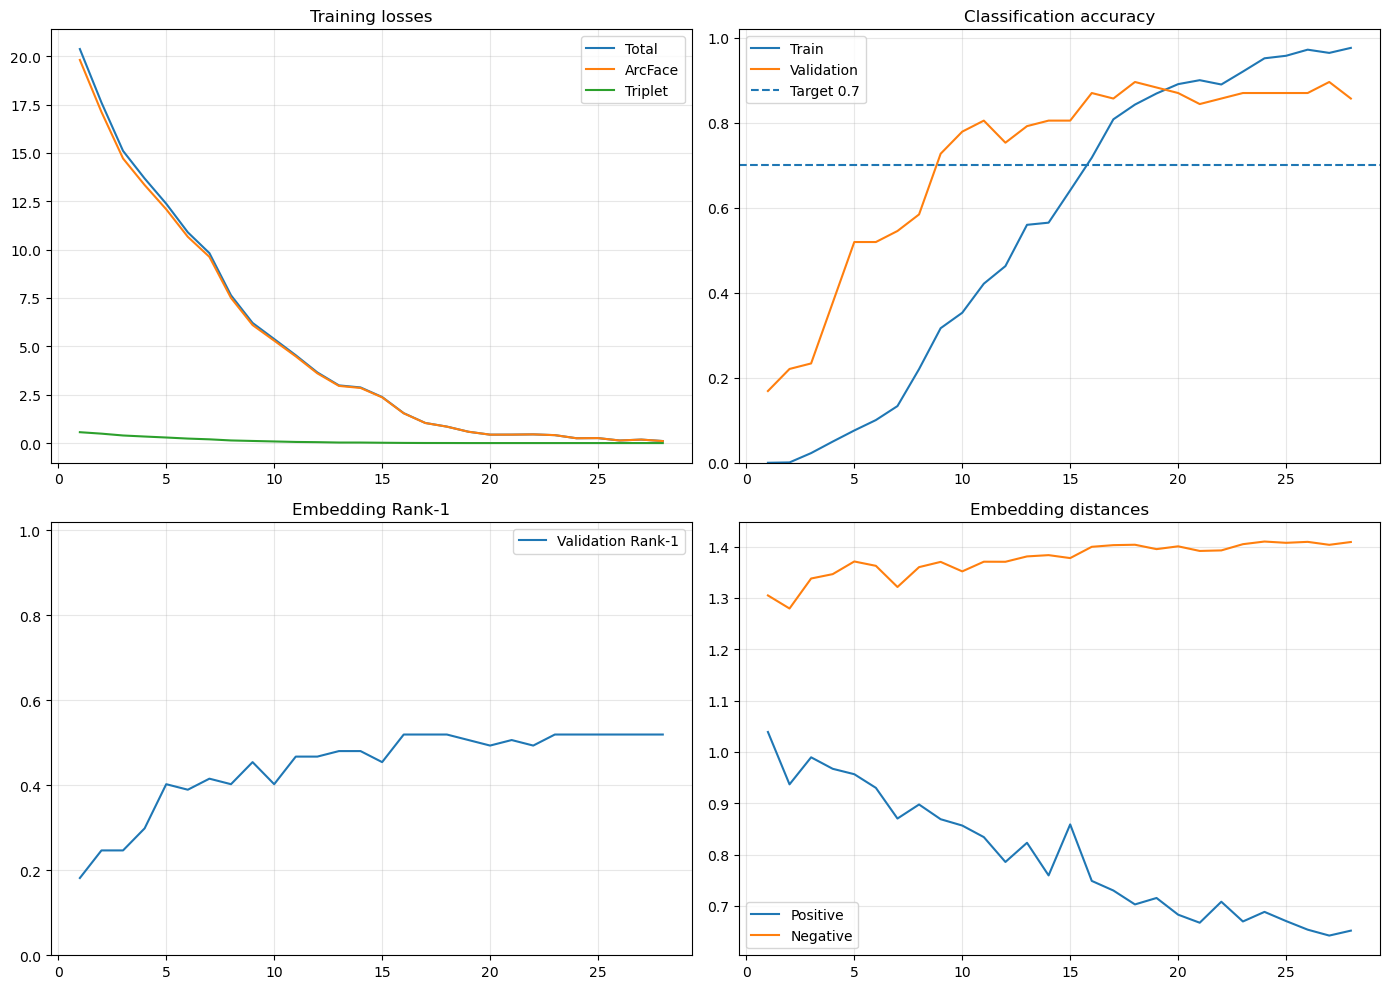

In [11]:
history_df = pd.DataFrame(history)
display(history_df.tail())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(
    history_df["epoch"],
    history_df["train_total_loss"],
    label="Total",
)
axes[0, 0].plot(
    history_df["epoch"],
    history_df["train_arcface_loss"],
    label="ArcFace",
)
axes[0, 0].plot(
    history_df["epoch"],
    history_df["train_triplet_loss"],
    label="Triplet",
)
axes[0, 0].set_title("Training losses")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train",
)
axes[0, 1].plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation",
)
axes[0, 1].axhline(
    0.7,
    linestyle="--",
    label="Target 0.7",
)
axes[0, 1].set_title("Classification accuracy")
axes[0, 1].set_ylim(0, 1.02)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(
    history_df["epoch"],
    history_df["val_rank1"],
    label="Validation Rank-1",
)
axes[1, 0].set_title("Embedding Rank-1")
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(
    history_df["epoch"],
    history_df["mean_positive_distance"],
    label="Positive",
)
axes[1, 1].plot(
    history_df["epoch"],
    history_df["mean_negative_distance"],
    label="Negative",
)
axes[1, 1].set_title("Embedding distances")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "arcface_triplet_training.png",
    dpi=150,
)

plt.show()

## 9. Загрузка лучшей модели и итоговая оценка

In [12]:
def load_best_model():
    checkpoint = torch.load(
        BEST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=False,
    )

    loaded_model = ArcFaceTripletModel(
        num_classes=int(
            checkpoint.get("num_classes", NUM_CLASSES)
        ),
        embedding_size=int(
            checkpoint.get("embedding_size", EMBEDDING_SIZE)
        ),
        s=float(
            checkpoint.get("arcface_scale", ARCFACE_SCALE)
        ),
        m=float(
            checkpoint.get("arcface_margin", ARCFACE_MARGIN)
        ),
    ).to(DEVICE)

    loaded_model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True,
    )

    loaded_model.eval()

    return loaded_model, checkpoint


best_model, best_checkpoint = load_best_model()

(
    final_embeddings,
    final_logits,
    final_labels,
    final_image_ids,
) = collect_validation_outputs(
    best_model,
    val_loader,
)

final_accuracy = classification_accuracy(
    final_logits,
    final_labels,
)

final_rank1 = leave_one_out_rank1_accuracy(
    final_embeddings,
    final_labels,
)

final_distances = distance_statistics(
    final_embeddings,
    final_labels,
)

print("=" * 70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ ARCFACE + TRIPLET LOSS")
print("=" * 70)

print(
    f"Validation Classification Accuracy: "
    f"{final_accuracy * 100:.2f}%"
)

print(
    f"Validation Rank-1 Accuracy: "
    f"{final_rank1 * 100:.2f}%"
)

print(
    "Mean positive distance:",
    f"{final_distances['mean_positive_distance']:.4f}",
)

print(
    "Mean negative distance:",
    f"{final_distances['mean_negative_distance']:.4f}",
)

if final_accuracy >= 0.70:
    print(
        "Достаточное качество достигнуто: "
        "accuracy >= 0.70"
    )
else:
    print(
        "Accuracy ниже 0.70. "
        "Можно увеличить EPOCHS или уменьшить TRIPLET_WEIGHT."
    )

print("=" * 70)

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

ИТОГОВЫЕ РЕЗУЛЬТАТЫ ARCFACE + TRIPLET LOSS
Validation Classification Accuracy: 89.61%
Validation Rank-1 Accuracy: 51.95%
Mean positive distance: 0.7027
Mean negative distance: 1.4038
Достаточное качество достигнуто: accuracy >= 0.70


## 10. Визуальные примеры ближайших соседей

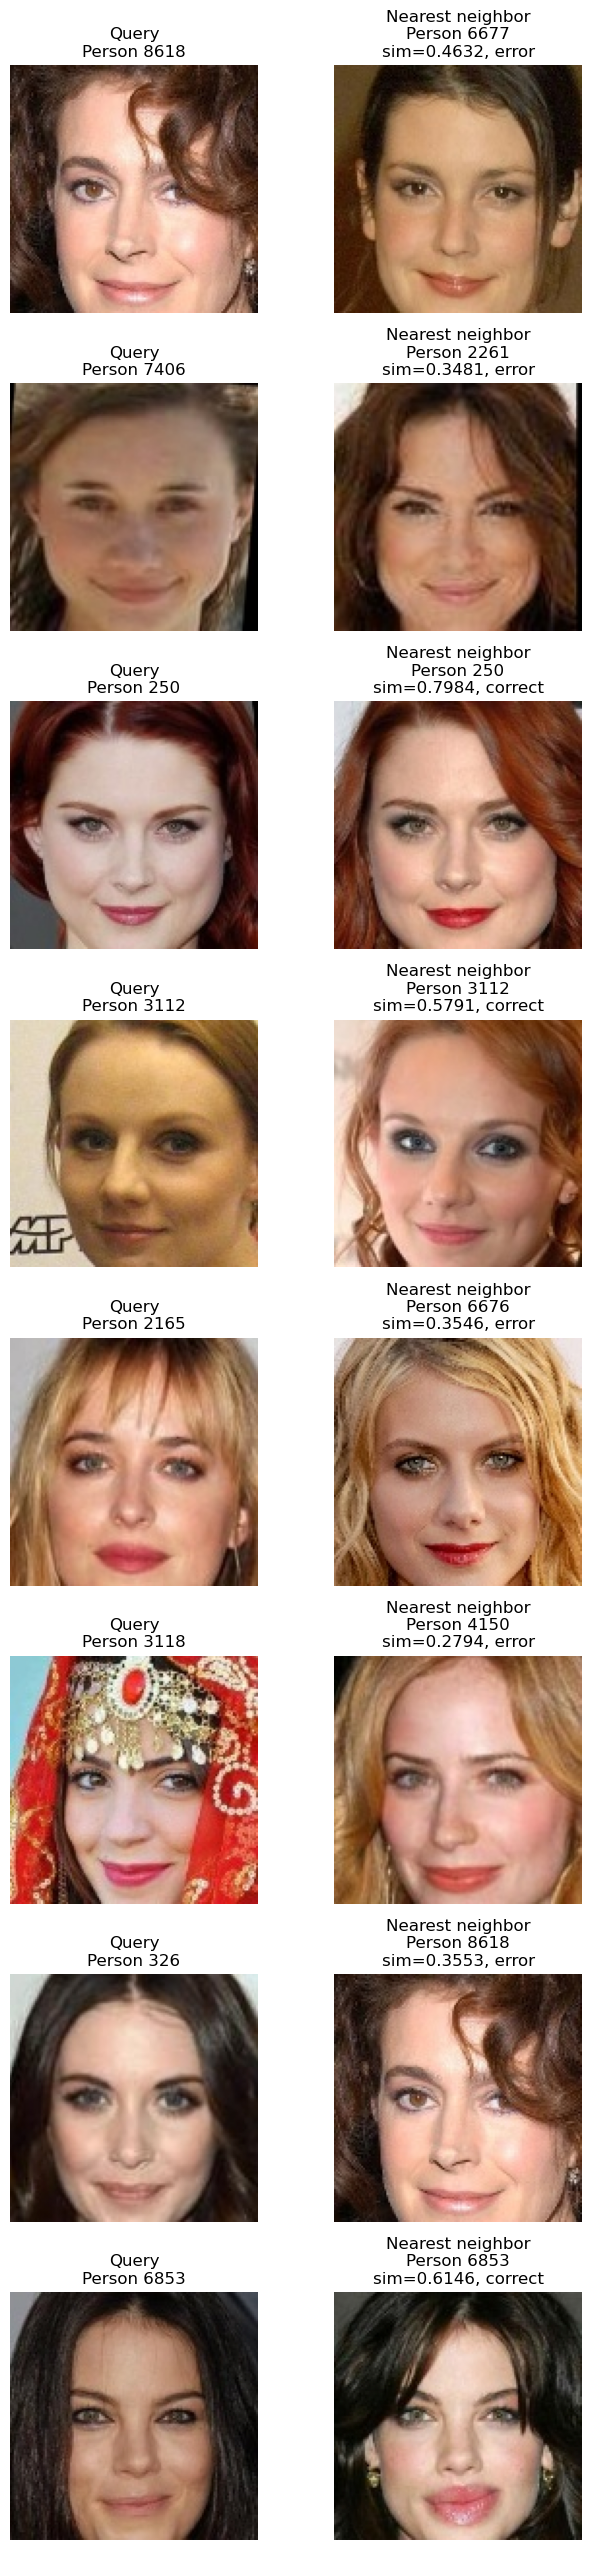

In [13]:
def read_rgb(path):
    image = cv2.imread(str(path))

    if image is None:
        raise FileNotFoundError(path)

    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def show_nearest_neighbor_examples(
    embeddings,
    labels,
    dataframe,
    number_of_examples=8,
    seed=42,
):
    similarities = embeddings @ embeddings.T

    np.fill_diagonal(similarities, -np.inf)

    nearest_indices = np.argmax(
        similarities,
        axis=1,
    )

    rng = np.random.default_rng(seed)

    selected_indices = rng.choice(
        np.arange(len(dataframe)),
        size=min(number_of_examples, len(dataframe)),
        replace=False,
    )

    figure, axes = plt.subplots(
        len(selected_indices),
        2,
        figsize=(7, 3.2 * len(selected_indices)),
    )

    if len(selected_indices) == 1:
        axes = np.asarray([axes])

    for row_index, query_index in enumerate(selected_indices):
        neighbor_index = nearest_indices[query_index]

        query_row = dataframe.iloc[query_index]
        neighbor_row = dataframe.iloc[neighbor_index]

        is_correct = (
            labels[query_index]
            == labels[neighbor_index]
        )

        similarity = similarities[
            query_index,
            neighbor_index,
        ]

        axes[row_index, 0].imshow(
            read_rgb(query_row["image_path"])
        )
        axes[row_index, 0].set_title(
            f"Query\nPerson {query_row['person_id']}"
        )
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(
            read_rgb(neighbor_row["image_path"])
        )
        axes[row_index, 1].set_title(
            f"Nearest neighbor\n"
            f"Person {neighbor_row['person_id']}\n"
            f"sim={similarity:.4f}, "
            f"{'correct' if is_correct else 'error'}"
        )
        axes[row_index, 1].axis("off")

        border_color = "green" if is_correct else "red"

        for spine in axes[row_index, 1].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(4)
            spine.set_edgecolor(border_color)

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "arcface_triplet_examples.png",
        dpi=150,
    )

    plt.show()


show_nearest_neighbor_examples(
    embeddings=final_embeddings,
    labels=final_labels,
    dataframe=val_df.reset_index(drop=True),
    number_of_examples=8,
)

## Контроль достаточного качества

Основной критерий в ноутбуке — `Validation Classification Accuracy >= 0.70`. Дополнительно оценивается `Rank-1 Accuracy`, которая показывает, как часто ближайший сосед в пространстве эмбеддингов принадлежит тому же человеку.

Важно: конкретное значение качества зависит от подготовленного датасета, числа идентичностей, качества выравнивания лиц и доступного времени обучения. Поэтому ноутбук не подставляет выдуманный результат: итоговые метрики вычисляются после фактического запуска. Лучший checkpoint автоматически сохраняется по validation accuracy.

Если порог не достигнут, сначала рекомендуется увеличить `EPOCHS`, затем уменьшить `TRIPLET_WEIGHT` до `0.3–0.5`, увеличить число изображений на класс и проверить качество выравнивания лиц.


## Вывод

Validation Classification Accuracy: 89.61%
